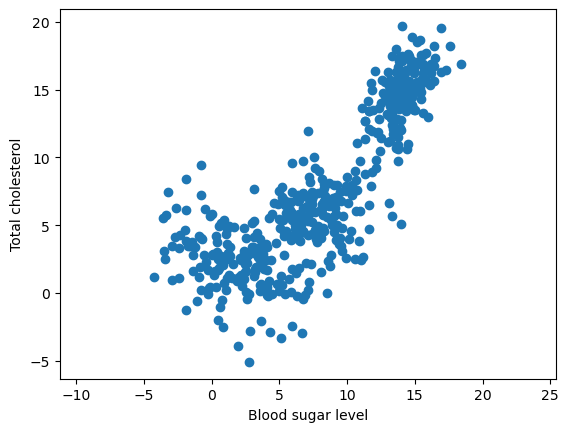

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.mixture import GaussianMixture


dataFilePath = 'bloodSugar_vs_cholesterol.csv'

X = np.loadtxt(dataFilePath, delimiter=',', skiprows=0)

plt.figure()
plt.plot(X[:,0],X[:,1],'o')
plt.xlabel("Blood sugar level")
plt.ylabel("Total cholesterol")
plt.axis('equal');

In [2]:
gm = GaussianMixture(n_components=3, random_state=0).fit(X)

print(gm.means_)

[[ 7.80606258  5.84605158]
 [ 1.76211659  2.14010964]
 [14.05074428 14.74932979]]


C:\Users\user\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\user\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\user\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\user\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\user\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(

In [3]:
hard_cluster = gm.predict(X)
print(hard_cluster)

soft_cluster = gm.predict_proba(X)

print(soft_cluster)

print("Weights:\n"+str(gm.weights_))
print("Means:\n"+str(gm.means_))
print("Covariance:\n"+str(gm.covariances_))


[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 0 1 1 1 1 0 1 1 1 1 1 1 1 0 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 0 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 2 1 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 

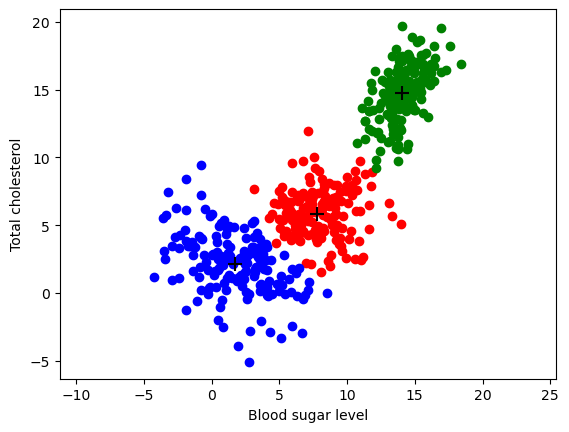

In [4]:
color_ls = ['r','b','g','m','y','c']
plt.figure()
for i, j in enumerate(np.unique(np.unique(hard_cluster))):
    plt.scatter(X[hard_cluster == j, 0], X[hard_cluster == j, 1],
                c = color_ls[j], label = 'cluster '+str(j+1))
    plt.scatter(gm.means_[j,0], gm.means_[j,1], c = 'k', marker='+', s=100) # plot cluster center (mean of Gaussian components)
plt.xlabel("Blood sugar level")
plt.ylabel("Total cholesterol")
plt.axis('equal');

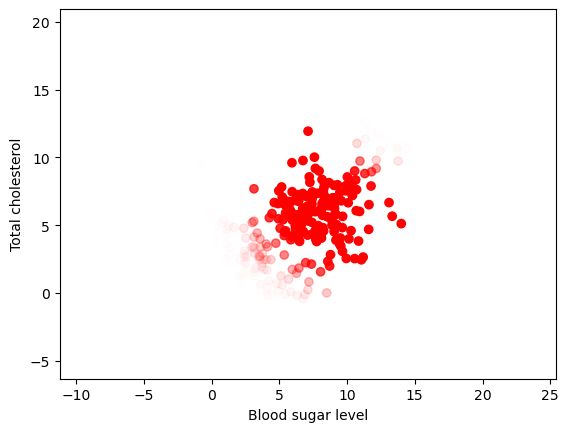

In [5]:
color_ls = ['r','b','g','m','y','c']

cluster2Plot = 0
plt.scatter(X[:, 0], X[:, 1], c = color_ls[cluster2Plot], alpha=soft_cluster[:,cluster2Plot])
    # plt.scatter(gm.means_[j,0], gm.means_[j,1], c = 'k', marker='+', s=100) # plot cluster center (mean of Gaussian components)
plt.xlabel("Blood sugar level")
plt.ylabel("Total cholesterol")
plt.axis('equal');

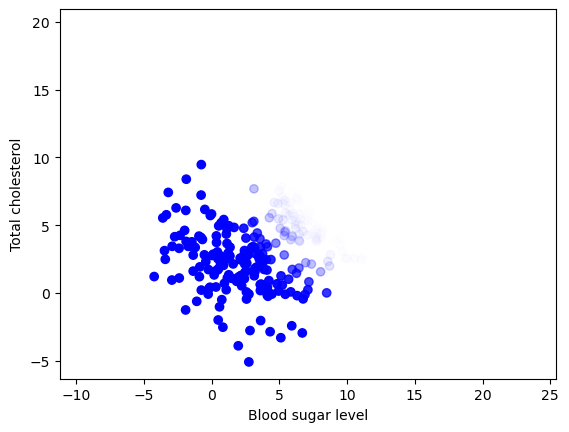

In [6]:
color_ls = ['r','b','g','m','y','c']

cluster2Plot = 1
plt.scatter(X[:, 0], X[:, 1], c = color_ls[cluster2Plot], alpha=soft_cluster[:,cluster2Plot])
    # plt.scatter(gm.means_[j,0], gm.means_[j,1], c = 'k', marker='+', s=100) # plot cluster center (mean of Gaussian components)
plt.xlabel("Blood sugar level")
plt.ylabel("Total cholesterol")
plt.axis('equal');

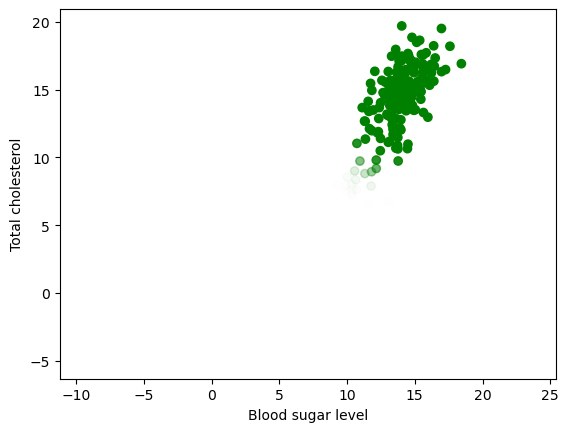

In [7]:
color_ls = ['r','b','g','m','y','c']

cluster2Plot = 2
plt.scatter(X[:, 0], X[:, 1], c = color_ls[cluster2Plot], alpha=soft_cluster[:,cluster2Plot])
    # plt.scatter(gm.means_[j,0], gm.means_[j,1], c = 'k', marker='+', s=100) # plot cluster center (mean of Gaussian components)
plt.xlabel("Blood sugar level")
plt.ylabel("Total cholesterol")
plt.axis('equal');